# Bike Regression — ทำนายจำนวนจักรยานที่ถูกเช่า

In [1]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(REPO))
import config
print("RANDOM_STATE =", config.RANDOM_STATE)

RANDOM_STATE = 42


## 1. ปัญหา / เป้าหมาย
**ทำนายอะไร:** จำนวนจักรยานสาธารณะที่ถูกเช่าในเมืองโซลใน 1 ชั่วโมง (`Rented Bike Count`) **หน่วย: คัน/ชั่วโมง** · เป็นงาน Regression เพราะค่าที่ทำนายเป็นตัวเลขต่อเนื่อง

**ตัวแปรนำเข้า:** ข้อมูลเวลา (วันที่, ชั่วโมง, วันหยุด) และสภาพอากาศ (อุณหภูมิ, ความชื้น, ความเร็วลม, ปริมาณฝน) · input ที่ใช้จริงในแอปจะเลือกและให้เหตุผลในหัวข้อ 5

**ประโยชน์:** ผู้ให้บริการรู้ล่วงหน้าว่าชั่วโมงไหนคนจะเช่ามากหรือน้อย จึงใช้ได้กับ
- เตรียมจักรยานให้พอในชั่วโมงที่ความต้องการสูง ไม่ให้ผู้ใช้หาจักรยานไม่ได้
- จัดคนงานย้ายจักรยานไปจุดต่างๆ ก่อนช่วงที่คนเช่าเยอะ
- เลือกช่วงที่ความต้องการต่ำไว้ซ่อมบำรุง


## 2. แหล่งข้อมูล
- **ชุดข้อมูล:** Seoul Bike Sharing Demand จาก [UCI Machine Learning Repository (id 560)](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand) · DOI: 10.24432/C5F62R
- **ไลเซนส์:** CC BY 4.0 นำไปใช้และเผยแพร่ต่อได้ โดยต้องอ้างอิงที่มา
- **ไฟล์:** `bike-regression/data/SeoulBikeData.csv`
- **ขนาด:** 8,760 แถว × 14 คอลัมน์ · 1 แถว = 1 ชั่วโมงของทั้งระบบ (ยอดรวมทุกสถานี) ตั้งแต่ 1 ธ.ค. 2017 ถึง 30 พ.ย. 2018

**คอลัมน์**
- **เป้าหมาย:** `Rented Bike Count` จำนวนจักรยานที่ถูกเช่าในชั่วโมงนั้น (คัน)
- **เวลา:** `Date` (วันที่), `Hour` (0–23), `Seasons` (ฤดู), `Holiday` (วันหยุดหรือไม่), `Functioning Day` (ระบบเปิดให้บริการหรือไม่)
- **สภาพอากาศ:** `Temperature(°C)`, `Humidity(%)`, `Wind speed (m/s)`, `Visibility (10m)`, `Dew point temperature(°C)`, `Solar Radiation (MJ/m2)`, `Rainfall(mm)`, `Snowfall (cm)`

## 3. โหลดและดูข้อมูล
- ดูโครงสร้างของข้อมูลทั้งชุด: encoding, ตารางตัวอย่าง, ชนิดข้อมูล, ค่าที่หายไป, ค่าในคอลัมน์หมวดหมู่

### 3.1 ตรวจ encoding และรูปแบบวันที่ของไฟล์ดิบ
**จุดประสงค์**
1. หา encoding ที่อ่านไฟล์ได้ถูกต้อง เพราะชื่อคอลัมน์มีสัญลักษณ์ `°` (เช่น `Temperature(°C)`) ถ้าเลือก encoding ผิด จะอ่านไฟล์ไม่ได้
2. หารูปแบบของคอลัมน์ `Date` (เช่น `01/12/2017`) ว่าเป็น วัน/เดือน หรือ เดือน/วัน ถ้าเลือกผิด วันที่จะสลับกัน และการแบ่งข้อมูลตามวันในขั้นถัดไปจะผิดตาม

In [2]:
import pandas as pd

# (ก) ดู byte ดิบของหัวตาราง ตรงคอลัมน์อุณหภูมิ
with open(config.BIKE_RAW_CSV, "rb") as f:
    header_bytes = f.readline()
i = header_bytes.find(b"Temperature")
print("bytes ของหัวคอลัมน์อุณหภูมิ:", header_bytes[i:i + 16])

# (ข) ลองอ่านหัวตารางด้วย 2 encoding
for enc in ["utf-8", "cp1252"]:
    try:
        cols = pd.read_csv(config.BIKE_RAW_CSV, encoding=enc, nrows=0).columns
        print(f"{enc} -> อ่านได้:", cols[3])
    except UnicodeDecodeError as e:
        print(f"{enc} -> อ่านไม่ได้:", e.reason)

# (ค) ตรวจรูปแบบวันที่: แยก "01/12/2017" เป็น 3 ส่วน แล้วดูค่าสูงสุดของแต่ละส่วน
dates = pd.read_csv(config.BIKE_RAW_CSV, encoding="cp1252", usecols=["Date"])["Date"] 
parts = dates.str.split("/", expand=True).astype(int)
print("ส่วนที่ 1 ค่าสูงสุด:", parts[0].max())
print("ส่วนที่ 2 ค่าสูงสุด:", parts[1].max())
print("ส่วนที่ 3 ค่าที่มี:", sorted(parts[2].unique().tolist()))

# (ง) แปลงเป็นวันที่ด้วยรูปแบบ วัน/เดือน/ปี แล้วตรวจช่วงวันที่และจำนวนวัน
parsed = pd.to_datetime(dates, format="%d/%m/%Y")
print("ช่วงวันที่:", parsed.min().date(), "ถึง", parsed.max().date())
print("จำนวนวัน:", parsed.nunique(), "| จำนวนแถว:", len(parsed))

bytes ของหัวคอลัมน์อุณหภูมิ: b'Temperature(\xb0C),'
utf-8 -> อ่านไม่ได้: invalid start byte
cp1252 -> อ่านได้: Temperature(°C)
ส่วนที่ 1 ค่าสูงสุด: 31
ส่วนที่ 2 ค่าสูงสุด: 12
ส่วนที่ 3 ค่าที่มี: [2017, 2018]
ช่วงวันที่: 2017-12-01 ถึง 2018-11-30
จำนวนวัน: 365 | จำนวนแถว: 8760


**ผลลัพธ์**
- `°` ถูกเก็บเป็น byte `\xb0`: อ่านด้วย `utf-8` ไม่ได้ แต่อ่านด้วย `cp1252` ได้ถูกต้อง → ใช้ `cp1252`
- วันที่ส่วนแรกมีค่าถึง 31 ส่วนที่สองไม่เกิน 12 → รูปแบบเป็น วัน/เดือน/ปี (`%d/%m/%Y`)
- ข้อมูลตั้งแต่ 1 ธ.ค. 2017 ถึง 30 พ.ย. 2018 มี 365 วัน × 24 ชม. = 8,760 แถว ไม่มีชั่วโมงไหนหาย
- บันทึกทั้งสองค่าไว้ใน `config.py`

### 3.2 โหลดข้อมูลและเปลี่ยนชื่อคอลัมน์
**จุดประสงค์**
- อ่านไฟล์ด้วย encoding ที่ตรวจแล้วใน 3.1 (`cp1252`)
- เปลี่ยนชื่อคอลัมน์เป็นแบบสั้นที่ไม่มีหน่วยหรืออักขระพิเศษ (เช่น `Temperature(°C)` → `temp_c`) เพื่อลดความผิดพลาดตอนเขียนโค้ด
- แปลงคอลัมน์ `date` จากข้อความเป็นวันที่จริง ด้วยรูปแบบที่ตรวจแล้วใน 3.1 (`%d/%m/%Y` = วัน/เดือน/ปี)

In [3]:
# อ่าน CSV ทั้งไฟล์ด้วย encoding ที่ตรวจแล้วใน 3.1 (cp1252)
df = pd.read_csv(config.BIKE_RAW_CSV, encoding=config.BIKE_RAW_ENCODING)

# ตรวจว่าชื่อคอลัมน์ในไฟล์ตรงกับ config ทุกตัวและทุกลำดับ (ไฟล์ถูกเปลี่ยน → หยุดทันที)
assert list(df.columns) == list(config.BIKE_COLUMN_MAP), "ชื่อคอลัมน์ไม่ตรงกับ config.BIKE_COLUMN_MAP"

# เปลี่ยนชื่อคอลัมน์เป็นแบบสั้น เช่น "Temperature(°C)" → "temp_c"
df = df.rename(columns=config.BIKE_COLUMN_MAP)

# แปลง date จากข้อความ (object) เป็นวันที่ (datetime64) ด้วยรูปแบบ วัน/เดือน/ปี
df[config.BIKE_DATE_COL] = pd.to_datetime(df[config.BIKE_DATE_COL], format=config.BIKE_DATE_FORMAT)

# แสดงขนาดตาราง (แถว, คอลัมน์) และ 5 แถวแรก
print("shape:", df.shape)
df.head()

shape: (8760, 14)


,date,rented_bike_count,hour,temp_c,humidity_pct,wind_speed_ms,visibility_10m,dew_point_c,solar_radiation_mj,rainfall_mm,snowfall_cm,seasons,holiday,functioning_day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


**ผลลัพธ์:** ได้ 8,760 แถว × 14 คอลัมน์ ชื่อคอลัมน์ตรงกับที่คาดทุกตัว · แถวแรกคือ 1 ธ.ค. 2017 เวลา 0:00 ยอดเช่า 254 คัน อุณหภูมิ −5.2 °C

### 3.3 ชนิดข้อมูลและความครบถ้วนของข้อมูล
**จุดประสงค์**
- ดูชนิดข้อมูลของแต่ละคอลัมน์ ว่าเป็นตัวเลข ข้อความ หรือวันที่ เพื่อรู้ว่าคอลัมน์ไหนต้องแปลงก่อนเข้าโมเดล
- ตรวจ missing value และแถวซ้ำ
- ตรวจว่าทุกวันมีครบ 24 ชั่วโมง (0–23) เพราะการแบ่งข้อมูลในหัวข้อ 4 ใช้ "วัน" เป็นหน่วย

In [4]:
# ชนิดข้อมูล (Dtype) และจำนวนค่าที่ไม่ว่าง (Non-Null) ของทุกคอลัมน์
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                8760 non-null   datetime64[ns]
 1   rented_bike_count   8760 non-null   int64         
 2   hour                8760 non-null   int64         
 3   temp_c              8760 non-null   float64       
 4   humidity_pct        8760 non-null   int64         
 5   wind_speed_ms       8760 non-null   float64       
 6   visibility_10m      8760 non-null   int64         
 7   dew_point_c         8760 non-null   float64       
 8   solar_radiation_mj  8760 non-null   float64       
 9   rainfall_mm         8760 non-null   float64       
 10  snowfall_cm         8760 non-null   float64       
 11  seasons             8760 non-null   object        
 12  holiday             8760 non-null   object        
 13  functioning_day     8760 non-null   object      

In [5]:
rows_per_day = df.groupby("date").size()  # นับจำนวนแถวของแต่ละวัน
hours_complete = (                        # เก็บผลว่าทุกวันมีชั่วโมงครบไหม (True/False)
    df.groupby("date")["hour"]            # จัดกลุ่มคอลัมน์ hour ตามวัน
    .apply(lambda h: sorted(h) == list(range(24)))  # แต่ละวัน: ชั่วโมงที่เรียงแล้วต้องเท่ากับ [0, 1, …, 23]
    .all()                                # ทุกวันต้องเป็น True จึงได้ True
)

checks = pd.Series({                                                       # รวมผลตรวจทุกข้อเป็นตารางเดียว
    "จำนวนแถว": len(df),                                                    # จำนวนแถวทั้งหมด
    "missing (รวมทุกคอลัมน์)": int(df.isna().sum().sum()),                   # นับ missing ต่อคอลัมน์ แล้วรวมทุกคอลัมน์
    "แถวซ้ำทั้งแถว": int(df.duplicated().sum()),                              # แถวที่ทุกคอลัมน์ซ้ำกับแถวก่อนหน้า
    "แถวซ้ำ (date, hour)": int(df.duplicated(["date", "hour"]).sum()),       # วันและชั่วโมงเดียวกันมีมากกว่า 1 แถว
    "วันแรก": df["date"].min().date(),                                       # วันที่เก่าที่สุด
    "วันสุดท้าย": df["date"].max().date(),                                   # วันที่ใหม่ที่สุด
    "จำนวนวัน": df["date"].nunique(),                                        # จำนวนวันที่ไม่ซ้ำกัน
    "แถวต่อวัน (min–max)": f"{rows_per_day.min()}–{rows_per_day.max()}",    # วันที่มีแถวน้อยสุดและมากสุด
    "ทุกวันมีชั่วโมง 0–23 ครบ": hours_complete,                               # ผลจากด้านบน
}, dtype=object)                                                           # object = ใส่ตัวเลข วันที่ ข้อความปนกันได้

# ขนาดข้อมูลต้องถูกต้อง: 8,760 แถว = 365 วัน × 24 ชม. และทุกวันมีชั่วโมง 0–23 ครบ
assert len(df) == 8760 and df["date"].nunique() == 365 and hours_complete
# ข้อมูลต้องสะอาด: ไม่มี missing และไม่มีชั่วโมงไหนซ้ำในวันเดียวกัน
assert df.isna().sum().sum() == 0 and df.duplicated(["date", "hour"]).sum() == 0
checks.to_frame("ค่า")  # แสดงผลเป็นตาราง 1 คอลัมน์ชื่อ "ค่า"

,ค่า
จำนวนแถว,8760
missing (รวมทุกคอลัมน์),0
แถวซ้ำทั้งแถว,0
"แถวซ้ำ (date, hour)",0
วันแรก,2017-12-01
วันสุดท้าย,2018-11-30
จำนวนวัน,365
แถวต่อวัน (min–max),24–24
ทุกวันมีชั่วโมง 0–23 ครบ,True


**ผลลัพธ์**
- `date` เป็น `datetime64` แล้ว · สภาพอากาศเป็นตัวเลข (int/float) · `seasons`, `holiday`, `functioning_day` เป็นข้อความ (`object`) → ต้องแปลงเป็นตัวเลขก่อนเข้าโมเดล
- **ไม่มี missing value** และไม่มีแถวซ้ำ
- 365 วัน ทุกวันมี 24 แถว ชั่วโมง 0–23 ครบ → ใช้ "วัน" เป็นหน่วยของการแบ่งข้อมูลได้

### 3.4 ค่าในคอลัมน์หมวดหมู่
**จุดประสงค์:** นับจำนวนแถวของแต่ละค่าในคอลัมน์ข้อความ (`seasons`, `holiday`, `functioning_day`) เพื่อตรวจว่ามีค่าสะกดผิดหรือมีช่องว่างเกินไหม (เช่น `"Yes "`) ก่อนนำไปแปลงเป็นตัวเลข

In [6]:
for c in ["seasons", "holiday", "functioning_day"]:    # วนทีละคอลัมน์ที่เป็นข้อความ
    counts = df[c].value_counts().to_dict()            # นับจำนวนแถวของแต่ละค่า แล้วแปลงเป็น {ค่า: จำนวน}
    print(f"{c:<16}", counts)                          # พิมพ์ชื่อคอลัมน์ (ชิดซ้าย กว้าง 16 ตัวอักษร) ตามด้วยผลนับ

seasons          {'Spring': 2208, 'Summer': 2208, 'Autumn': 2184, 'Winter': 2160}
holiday          {'No Holiday': 8328, 'Holiday': 432}
functioning_day  {'Yes': 8465, 'No': 295}


**ผลลัพธ์**
- `seasons` มี 4 ค่า (Spring, Summer, Autumn, Winter) จำนวนแถวใกล้กัน (2,160–2,208) เพราะแต่ละฤดูยาวประมาณ 90 วัน
- `holiday` มี 2 ค่า: `Holiday` 432 แถว (= 18 วันหยุด × 24 ชม.) · `No Holiday` 8,328 แถว
- `functioning_day` มี 2 ค่า: `No` **295 แถว** คือชั่วโมงที่ระบบปิดให้บริการ → จะวิเคราะห์ในหัวข้อ 5 (บน train)
- ไม่มีค่าสะกดผิดหรือมีช่องว่างเกิน → แปลงเป็นตัวเลขได้ตรงๆ

## 4. แบ่งข้อมูล
**จุดประสงค์:** กันข้อมูลส่วนหนึ่ง (test) ไว้วัดผลตอนท้ายครั้งเดียว โมเดลต้องไม่เคยเห็นข้อมูลส่วนนี้ตอนฝึกหรือตอนเลือกโมเดล

**วิธีแบ่ง:** สุ่มแบ่ง **ตามวัน** ไม่สุ่มทีละแถว
- 1 วันมี 24 แถว และชั่วโมงติดกันมีอากาศกับยอดเช่าใกล้กันมาก ถ้าชั่วโมงหนึ่งอยู่ train แต่ชั่วโมงถัดไปอยู่ test โมเดลจะแค่จำวันนั้นได้ คะแนน test จะสูงเกินจริง (leakage)
- ใช้ `GroupShuffleSplit(test_size=0.2, random_state=42)` โดยให้ `groups` เป็นวันที่ ทั้ง 24 ชม. ของวันเดียวกันจึงไปอยู่ฝั่งเดียวกันเสมอ
- เรียงข้อมูลตาม (วัน, ชั่วโมง) ก่อนสุ่ม รันกี่ครั้งก็ได้ผลเดิม
- บันทึกรายการวันไว้ที่ `bike-regression/data/splits/` เพื่อให้ทุกส่วนใช้วันชุดเดียวกัน
- ไฟล์ split สร้างด้วย `scripts/make_bike_split.py` ซึ่งใช้ logic เดียวกับ repo `seoul-bike-demand` ทุกขั้น → ได้วัน train/test **ชุดเดียวกันทุก byte** (ผลของสองวิชาเทียบกันได้)

In [7]:
# import ที่ใช้ในหัวข้อนี้ (ประกาศตรงนี้เพื่อให้เซลล์ข้างบนรันได้ตามลำดับ)
import numpy as np

### 4.1 สร้าง/โหลดรายการวัน train–test
**จุดประสงค์:** รัน `make_bike_split.py` (ถ้ายังไม่มีไฟล์) แล้วแยก `df` เป็น `train_df` / `test_df` ตามรายการวัน ไม่สุ่มใหม่ใน notebook

In [8]:
import subprocess

# ถ้ายังไม่มีไฟล์ split → เรียกสคริปต์สร้าง (สคริปต์เป็นที่เดียวที่สุ่ม ทุกคนจึงได้วันชุดเดียวกัน)
if not (config.BIKE_TRAIN_DATES.exists() and config.BIKE_TEST_DATES.exists()):
    subprocess.run([sys.executable, str(REPO / "scripts" / "make_bike_split.py")], check=True)

train_dates = pd.to_datetime(pd.read_csv(config.BIKE_TRAIN_DATES)["date"])
test_dates = pd.to_datetime(pd.read_csv(config.BIKE_TEST_DATES)["date"])
assert not set(train_dates) & set(test_dates), "มีวันที่อยู่ทั้ง train และ test"

train_df = df[df["date"].isin(train_dates)].sort_values(["date", "hour"]).reset_index(drop=True)
test_df = df[df["date"].isin(test_dates)].sort_values(["date", "hour"]).reset_index(drop=True)
assert len(train_df) + len(test_df) == len(df)          # ทุกแถวอยู่ฝั่งใดฝั่งหนึ่ง ไม่หาย ไม่ซ้ำ

print(f"train: {train_df.shape[0]:,} แถว | {train_df['date'].nunique()} วัน ({train_df['date'].nunique() / df['date'].nunique():.1%})")
print(f"test : {test_df.shape[0]:,} แถว | {test_df['date'].nunique()} วัน")
print("วัน test 5 วันแรก:", list(test_dates.dt.strftime('%Y-%m-%d')[:5]))

train: 7,008 แถว | 292 วัน (80.0%)
test : 1,752 แถว | 73 วัน
วัน test 5 วันแรก: ['2017-12-01', '2017-12-04', '2017-12-06', '2017-12-10', '2017-12-16']


### 4.2 ตรวจความสมดุลของสองฝั่ง
**จุดประสงค์:** ดูว่าฤดู วันหยุด และชั่วโมงที่ระบบปิด กระจายในสองฝั่งใกล้กันไหม ถ้าต่างกันมาก ผล test จะเอียงตามฤดู ต้องนำไปตีความในหัวข้อ 7
(ดูเฉพาะ "สัดส่วน" ของตัวแปรเวลา/ปฏิทิน ไม่ดูค่า target ของ test)

In [9]:
side = np.where(df["date"].isin(test_dates), "test", "train")
season_share = pd.crosstab(df["seasons"], side, colnames=["side"], normalize="columns").mul(100).round(1)
print("สัดส่วนแถวตามฤดู (%)")
print(season_share, "\n")

summary = df.assign(side=side).groupby("side").agg(
    days=("date", "nunique"),
    holiday_days=("date", lambda d: d[df.loc[d.index, "holiday"] == "Holiday"].nunique()),
    closed_hours=("functioning_day", lambda s: (s == "No").sum()),
)
summary

สัดส่วนแถวตามฤดู (%)
side     test  train
seasons             
Autumn   27.4   24.3
Spring   19.2   26.7
Summer   21.9   26.0
Winter   31.5   22.9 



,days,holiday_days,closed_hours
side,,,
test,73,6,55
train,292,12,240


**ผลลัพธ์**
- train **292 วัน / 7,008 แถว** · test **73 วัน / 1,752 แถว** (80/20 ตามวันพอดี) · ตรงกับ `seoul-bike-demand/data/README.md` ทุกตัวเลข
- ฤดูในสองฝั่งไม่เท่ากันเป๊ะ: test มีฤดูหนาวมากกว่า (≈31% vs ≈23%) และฤดูใบไม้ผลิน้อยกว่า → ฤดูหนาวยอดเช่าต่ำ ค่า MAE บน test อาจต่ำกว่าบน CV เล็กน้อย ต้องระวังตอนตีความ
- วันหยุดนักขัตฤกษ์: train 12 วัน, test 6 วัน · ชั่วโมงที่ระบบปิดอยู่ทั้งสองฝั่ง (train 240, test 55) → กฎจัดการต้องใช้ได้กับทั้งสองฝั่ง
- **จากนี้ไปวิเคราะห์และตัดสินใจจาก `train_df` เท่านั้น** `test_df` ใช้ครั้งเดียวในหัวข้อ 7

## 5. EDA และเตรียมข้อมูล (train เท่านั้น)
ทุกกราฟและตัวเลขในหัวข้อนี้มาจาก `train_df` (292 วัน) · การตัดสินใจทุกข้อ (กฎตัดแถว, feature, input ของแอป) ทำจากหลักฐานในหัวข้อนี้

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)

### 5.1 การกระจายของยอดเช่า และชั่วโมงที่ระบบปิด
**จุดประสงค์:** ดูสเกลและรูปร่างของ target (ใช้ตีความ MAE ทีหลัง) และตรวจว่าชั่วโมงที่ `functioning_day = No` มียอดเป็นเท่าไร

count    7008.0
mean      730.9
std       653.8
min         0.0
25%       206.0
50%       547.0
75%      1101.0
max      3556.0
skewness = 1.08 | ยอด = 0: 240 แถว

                 count      sum   max
functioning_day                      
No                 240        0     0
Yes               6768  5121877  3556


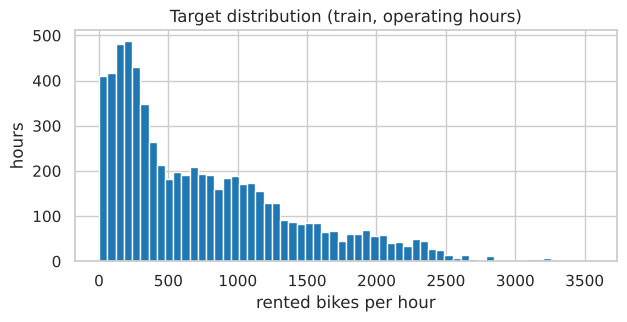

In [11]:
y_all = train_df["rented_bike_count"]
print(y_all.describe().round(1).to_string())
print(f"skewness = {y_all.skew():.2f} | ยอด = 0: {(y_all == 0).sum()} แถว")
print()
print(train_df.groupby("functioning_day")["rented_bike_count"].agg(["count", "sum", "max"]))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(y_all[train_df["functioning_day"] == "Yes"], bins=60, color="tab:blue")
ax.set(xlabel="rented bikes per hour", ylabel="hours", title="Target distribution (train, operating hours)")
plt.show()

**ผลลัพธ์**
- ยอดเช่าเฉลี่ย **731** คัน/ชม. · มัธยฐาน **547** · สูงสุด 3,556 · เบ้ขวา (skew ≈ 1.08) → ชั่วโมงส่วนใหญ่ยอดไม่สูง มีพีคไม่กี่ชั่วโมงที่ยอดสูงมาก
- ยอด = 0 มี 240 แถว และ **ทั้ง 240 แถวคือชั่วโมงที่ระบบปิด** (`functioning_day = No` ผลรวม = 0, max = 0) · ชั่วโมงที่ระบบเปิดไม่มียอด 0 เลย
- **ตัดสินใจ:** ตัดชั่วโมงที่ระบบปิดออกจากการฝึก ไม่ใช่สิ่งที่โมเดลต้องเรียน (คำตอบคือ 0 เสมอ) · แอปจะทำนายเฉพาะกรณี "ระบบเปิดให้บริการ" และเขียนข้อจำกัดนี้ไว้ในแอป

### 5.2 รูปแบบรายชั่วโมง: วันธรรมดา vs เสาร์-อาทิตย์
**จุดประสงค์:** ดูว่าชั่วโมงสำคัญแค่ไหน และรูปแบบรายชั่วโมงเปลี่ยนตามประเภทวันหรือไม่

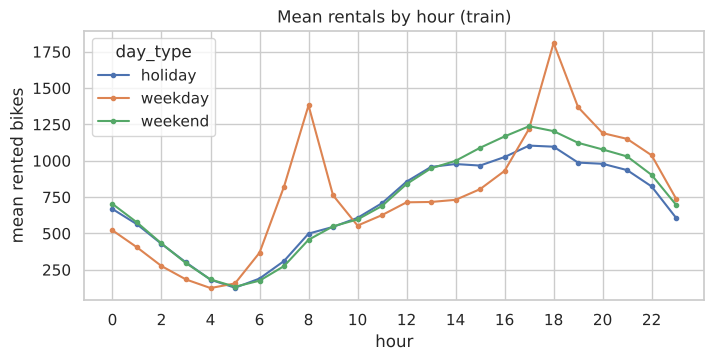

day_type  holiday  weekday  weekend
hour                               
4           182.0    124.0    183.0
8           499.0   1381.0    456.0
12          856.0    714.0    840.0
18         1097.0   1810.0   1204.0
21          936.0   1151.0   1030.0

ค่าเฉลี่ยตามวันในสัปดาห์ (0=จ.): {0: 736.0, 1: 749.0, 2: 811.0, 3: 743.0, 4: 816.0, 5: 750.0, 6: 682.0}


In [12]:
op = train_df[train_df["functioning_day"] == "Yes"].copy()      # เฉพาะชั่วโมงที่ระบบเปิด
op["day_type"] = np.where(op["date"].dt.dayofweek >= 5, "weekend", "weekday")
op.loc[op["holiday"] == "Holiday", "day_type"] = "holiday"

hourly = op.groupby(["hour", "day_type"])["rented_bike_count"].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 3.5))
hourly.plot(ax=ax, marker="o", ms=3)
ax.set(xlabel="hour", ylabel="mean rented bikes", title="Mean rentals by hour (train)", xticks=range(0, 24, 2))
plt.show()

print(hourly.loc[[4, 8, 12, 18, 21]].round(0))
print("\nค่าเฉลี่ยตามวันในสัปดาห์ (0=จ.):", op.groupby(op["date"].dt.dayofweek)["rented_bike_count"].mean().round(0).to_dict())

**ผลลัพธ์**
- ชั่วโมงเป็นตัวแปรที่แรงที่สุดด้านเวลา: ตี 4 เฉลี่ยราว 120–180 คัน แต่ 18:00 วันธรรมดาสูงถึง ~1,810 คัน (ต่างกันกว่า 10 เท่า)
- **วันธรรมดามีพีค 2 ช่วง** 8:00 และ 18:00 (เดินทางไป-กลับที่ทำงาน) · **เสาร์-อาทิตย์และวันหยุดไม่มีพีคเช้า** (8:00 วันธรรมดา ~1,380 vs วันหยุด ~500) ยอดค่อยๆ ขึ้นช่วงบ่าย → ผลของชั่วโมงขึ้นกับประเภทวัน (interaction) โมเดลต้องเห็นทั้งสองตัว
- ค่าเฉลี่ยรายวัน จ.–อา. ใกล้กัน (682–816) แปลว่าความต่างอยู่ที่ "รูปร่าง" ของวัน ไม่ใช่ยอดรวม → ใช้แค่ `is_weekend` (2 ค่า) แทนวันในสัปดาห์ 7 ค่าได้ ผู้ใช้กรอกง่ายกว่า

### 5.3 ฤดู อุณหภูมิ และฝน
**จุดประสงค์:** ดูผลของสภาพอากาศหลักต่อยอดเช่า

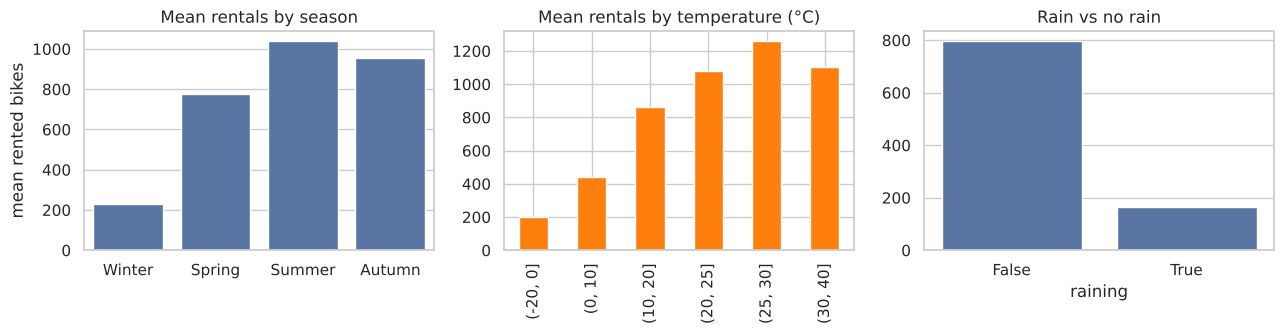

ฤดู: {'Autumn': 957.0, 'Spring': 774.0, 'Summer': 1037.0, 'Winter': 230.0}
อุณหภูมิ: {Interval(-20, 0, closed='right'): 203.0, Interval(0, 10, closed='right'): 439.0, Interval(10, 20, closed='right'): 861.0, Interval(20, 25, closed='right'): 1080.0, Interval(25, 30, closed='right'): 1258.0, Interval(30, 40, closed='right'): 1103.0}
             mean  count
is_raining              
False       795.0   6355
True        164.0    413


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
order = ["Winter", "Spring", "Summer", "Autumn"]
sns.barplot(data=op, x="seasons", y="rented_bike_count", order=order, errorbar=None, ax=axes[0])
axes[0].set(title="Mean rentals by season", xlabel="", ylabel="mean rented bikes")

temp_bins = pd.cut(op["temp_c"], [-20, 0, 10, 20, 25, 30, 40])
op.groupby(temp_bins, observed=True)["rented_bike_count"].mean().plot.bar(ax=axes[1], color="tab:orange")
axes[1].set(title="Mean rentals by temperature (°C)", xlabel="", ylabel="")

op["is_raining"] = op["rainfall_mm"] > 0
sns.barplot(data=op, x="is_raining", y="rented_bike_count", errorbar=None, ax=axes[2])
axes[2].set(title="Rain vs no rain", xlabel="raining", ylabel="")
plt.tight_layout()
plt.show()

print("ฤดู:", op.groupby("seasons")["rented_bike_count"].mean().round(0).to_dict())
print("อุณหภูมิ:", op.groupby(temp_bins, observed=True)["rented_bike_count"].mean().round(0).to_dict())
print(op.groupby("is_raining")["rented_bike_count"].agg(["mean", "count"]).round(0))

**ผลลัพธ์**
- **ฤดู:** หนาว **230** · ใบไม้ผลิ 774 · ใบไม้ร่วง 957 · ร้อน **1,037** คัน/ชม. → ต่างกันราว 4.5 เท่า
- **อุณหภูมิ:** ยอดเพิ่มตามอุณหภูมิจนถึงช่วง 25–30 °C (~1,260) แล้ว **ลดลง** เมื่อเกิน 30 °C (~1,100) → ความสัมพันธ์ไม่เป็นเส้นตรง โมเดลแบบ tree จับรูปร่างนี้ได้ดีกว่าเส้นตรง
- **ฝน:** ชั่วโมงที่ฝนตกยอดเฉลี่ย **164** เทียบกับ **795** ตอนไม่ตก (ลดลงราว 80%) แต่มีแค่ 413 ชั่วโมง (~6% ของ train) → โมเดลมีตัวอย่างฝนตกน้อย คาดว่าจะทายผิดมากในช่วงนี้

### 5.4 Correlation และตัวแปรที่ซ้ำซ้อน
**จุดประสงค์:** ดูความสัมพันธ์เชิงเส้นของตัวแปรตัวเลขกับ target และหาคู่ตัวแปรที่ให้ข้อมูลซ้ำกัน

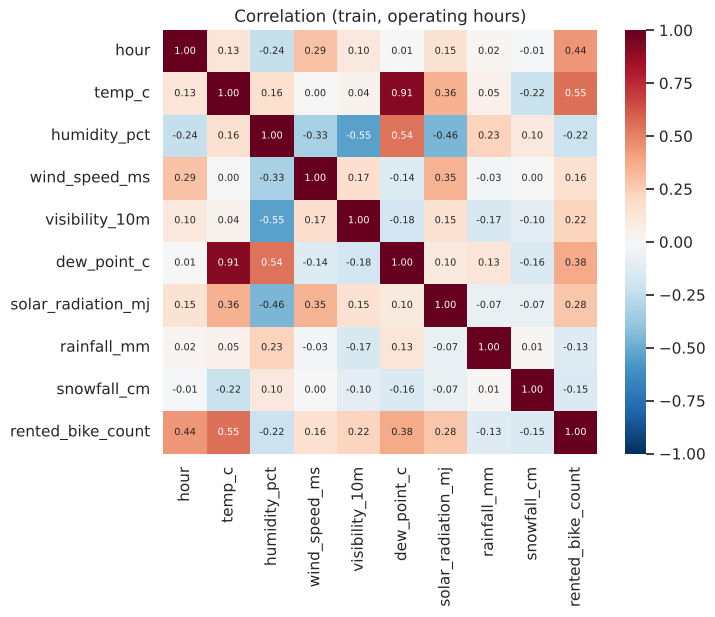

corr กับ target: {'temp_c': 0.55, 'hour': 0.44, 'dew_point_c': 0.38, 'solar_radiation_mj': 0.28, 'visibility_10m': 0.22, 'humidity_pct': -0.22, 'wind_speed_ms': 0.16, 'snowfall_cm': -0.15, 'rainfall_mm': -0.13}
temp_c vs dew_point_c: 0.911


In [14]:
NUM_COLS = ["hour", "temp_c", "humidity_pct", "wind_speed_ms", "visibility_10m",
            "dew_point_c", "solar_radiation_mj", "rainfall_mm", "snowfall_cm"]
corr = op[NUM_COLS + ["rented_bike_count"]].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation (train, operating hours)")
plt.show()

print("corr กับ target:", corr["rented_bike_count"].drop("rented_bike_count").sort_values(key=abs, ascending=False).round(2).to_dict())
print("temp_c vs dew_point_c:", round(corr.loc["temp_c", "dew_point_c"], 3))

**ผลลัพธ์**
- corr กับ target สูงสุด: `temp_c` **0.55** · `hour` 0.44 · `dew_point_c` 0.38 · `solar_radiation_mj` 0.28 · `humidity_pct` −0.22 (corr วัดแค่เชิงเส้น ชั่วโมงกับฝนจริงๆ มีผลมากกว่าตัวเลขนี้ ตามที่เห็นใน 5.2–5.3)
- `temp_c` กับ `dew_point_c` corr **0.91** → ซ้ำซ้อนกันมาก และจุดน้ำค้างคำนวณได้จากอุณหภูมิ+ความชื้นอยู่แล้ว (สูตร Magnus) → ไม่ต้องใช้ทั้งคู่

### 5.5 ค่าผิดปกติ: ความชื้น 0%
**จุดประสงค์:** ตรวจค่าที่เป็นไปไม่ได้ทางกายภาพ

In [15]:
bad_hum = op[op["humidity_pct"] == 0]
print(f"humidity = 0%: {len(bad_hum)} แถว ใน {bad_hum['date'].nunique()} วัน:",
      sorted(bad_hum["date"].dt.strftime("%Y-%m-%d").unique()))
print("ช่วงความชื้นเมื่อไม่นับ 0:", op.loc[op["humidity_pct"] > 0, "humidity_pct"].agg(["min", "max"]).to_dict())

humidity = 0%: 17 แถว ใน 5 วัน: ['2018-05-19', '2018-05-21', '2018-05-22', '2018-05-27', '2018-05-28']
ช่วงความชื้นเมื่อไม่นับ 0: {'min': 10, 'max': 98}


**ผลลัพธ์:** ความชื้น 0% มี 17 แถว กระจุกอยู่ 5 วันในเดือน พ.ค. 2018 ทั้งที่ค่าต่ำสุดอื่นๆ อยู่ราว 10% ขึ้นไป · อากาศในโซลไม่มีทางแห้งเป็น 0% → น่าจะเป็นเซนเซอร์ขัดข้อง
**ตัดสินใจ:** ตัด 17 แถวนี้ออกจาก train (0.25% ของข้อมูล) แทนการเติมค่า เพื่อไม่ต้องใส่ขั้นตอนเพิ่มใน Pipeline · แอปรับความชื้นเฉพาะ 1–100%

### 5.6 กฎเตรียมข้อมูลและ feature ที่สร้างเพิ่ม
**จุดประสงค์:** รวมการตัดสินใจจาก 5.1–5.5 เป็นฟังก์ชันเดียว ใช้กับ train และ test แบบเดียวกัน
- ตัดชั่วโมงที่ระบบปิด (5.1) และความชื้น 0% (5.5) — เป็นกฎตายตัวรายแถว ไม่ได้เรียนค่าจากข้อมูล จึงใช้กับ test ได้โดยไม่รั่ว
- สร้าง `is_weekend` (5.2) และ `is_holiday` (แปลงข้อความเป็น 0/1)

In [16]:
def prepare(df):
    out = df[(df["functioning_day"] == "Yes") & (df["humidity_pct"] > 0)].copy()
    out["is_weekend"] = (out["date"].dt.dayofweek >= 5).astype(int)     # ส.–อา. = 1
    out["is_holiday"] = (out["holiday"] == "Holiday").astype(int)
    return out.reset_index(drop=True)


train = prepare(train_df)
test = prepare(test_df)
print(f"train: {len(train_df):,} -> {len(train):,} แถว ({train['date'].nunique()} วัน)")
print(f"test : {len(test_df):,} -> {len(test):,} แถว")

train: 7,008 -> 6,751 แถว (282 วัน)
test : 1,752 -> 1,697 แถว


### 5.7 เลือก input ของแอป (≤ 8 feature)
**เกณฑ์:** (1) มีผลต่อยอดเช่าตามหลักฐานด้านบน (2) **ผู้ใช้รู้ค่าได้จริง** จากพยากรณ์อากาศทั่วไปหรือปฏิทิน (3) ไม่ซ้ำซ้อนกับตัวอื่น

| feature | ใช้ในแอป | เหตุผล |
|---|---|---|
| `hour` | ✅ | ตัวแปรเวลาที่แรงที่สุด (5.2) |
| `temp_c` | ✅ | corr สูงสุด 0.55 และไม่เป็นเส้นตรง (5.3, 5.4) |
| `humidity_pct` | ✅ | corr −0.22 · มีในพยากรณ์อากาศทั่วไป |
| `rainfall_mm` | ✅ | ฝนตกยอดลด ~80% (5.3) |
| `wind_speed_ms` | ✅ | มีในพยากรณ์อากาศ · corr 0.16 |
| `seasons` | ✅ | ต่างกัน 4.5 เท่า (5.3) |
| `is_weekend` | ✅ | รูปแบบรายชั่วโมงต่างกันชัด (5.2) |
| `is_holiday` | ✅ | วันหยุดรูปแบบเหมือนวันหยุดสุดสัปดาห์ (5.2) |
| `dew_point_c` | ❌ | ซ้ำกับ temp+humidity (corr 0.91) และคนทั่วไปไม่รู้ค่า |
| `solar_radiation_mj` | ❌ | คนทั่วไปไม่มีค่านี้ · ส่วนใหญ่สะท้อนชั่วโมง/ฤดูซึ่งมีแล้ว |
| `visibility_10m` | ❌ | ไม่อยู่ในพยากรณ์ทั่วไป · corr 0.22 |
| `snowfall_cm` | ❌ | มีแค่ฤดูหนาวซึ่ง `seasons` + `temp_c` ครอบคลุมแล้ว |

ราคาที่ต้องจ่ายจากการตัด 4 ตัวหลัง (ความแม่นที่ลดลง) จะวัดจริงด้วย CV ในหัวข้อ 6.3

In [17]:
APP_FEATURES = ["hour", "temp_c", "humidity_pct", "rainfall_mm", "wind_speed_ms",
                "seasons", "is_weekend", "is_holiday"]
EXTRA_FEATURES = ["dew_point_c", "solar_radiation_mj", "visibility_10m", "snowfall_cm"]
TARGET = config.BIKE_TARGET_COL
assert len(APP_FEATURES) <= 8

X_train, y_train, groups = train[APP_FEATURES], train[TARGET], train["date"]
X_test, y_test = test[APP_FEATURES], test[TARGET]     # ไม่ดูค่าใดๆ ของ test จนถึงหัวข้อ 7
print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| groups:", groups.nunique(), "วัน")
# ช่วงค่าใน train → ใช้กำหนดช่วงที่แอปยอมรับ (นอกช่วงนี้โมเดลไม่เคยเห็น)
X_train.describe().loc[["min", "max"]].round(1)

X_train: (6751, 8) | X_test: (1697, 8) | groups: 282 วัน


,hour,temp_c,humidity_pct,rainfall_mm,wind_speed_ms,is_weekend,is_holiday
min,0.0,-16.2,10.0,0.0,0.0,0.0,0.0
max,23.0,39.4,98.0,35.0,7.4,1.0,1.0


## 6. Train + เหตุผล
- TODO: preprocessing + model ใน `Pipeline` เดียว
- TODO: baseline + เทียบ 4 โมเดลด้วย `GroupKFold` (group = วันที่) บน train แล้ว tune ตัวที่ดีที่สุด

In [18]:
# TODO

## 7. ประเมินบน test + แปลความหมาย
- เมตริก: **MAE (หลัก, คัน/ชม.)**, RMSE, R²
- ⚠️ MAPE ใช้ตรงๆ ไม่ได้ เพราะมียอด = 0
- TODO: แปลความหมาย MAE เทียบกับยอดเช่าเฉลี่ย

In [19]:
# TODO

## 8. ตัวอย่างผลทำนาย + error analysis
- TODO: ตัวอย่างทำนาย 3–5 แถว · residual vs ชั่วโมง/ฤดู · ช่วงที่ผิดมาก

In [20]:
# TODO

## 9. บันทึกโมเดล → `app/model.joblib`
- TODO: `joblib.dump(pipeline, config.BIKE_MODEL)` — ทั้ง Pipeline ไฟล์เดียว
- ⚠️ เช็กขนาดไฟล์ < 100 MB · ลองโหลดกลับแล้วทำนายซ้ำให้ได้ค่าเดิม

In [21]:
# TODO